# Predicting Stellar Class

Link to Competittion: https://www.kaggle.com/competitions/playground-series-s6e6/overview

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (12, 6)

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

import xgboost as xgb

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, accuracy_score, confusion_matrix, mean_squared_error, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, RandomizedSearchCV, train_test_split
from sklearn.cluster import KMeans

from common import *

In [2]:
from platform import python_version
print('python: ', python_version())
print('pandas: ', pd.__version__)
print('numpy: ', np.__version__)
import matplotlib
print('matplotlib: ', matplotlib.__version__)
print('seaborn: ', sns.__version__)
import sklearn
print('sklearn: ', sklearn.__version__)
print('xgboost: ', xgb.__version__)

python:  3.13.13
pandas:  2.3.3
numpy:  2.4.6
matplotlib:  3.10.9
seaborn:  0.13.2
sklearn:  1.9.0
xgboost:  3.2.0


## Helpers

## Load data

In [3]:
train_df = pd.read_csv('archive/train.csv')
test_df = pd.read_csv('archive/test.csv')
orig_df = pd.read_csv('archive/star_classification.csv')

In [4]:
train_df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [6]:
train_df['class'].value_counts(normalize=True)

class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64

In [7]:
train_df['spectral_type'].value_counts()

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

In [8]:
train_df['galaxy_population'].value_counts()

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  object 
 10  galaxy_population  247435 non-null  object 
dtypes: float64(8), int64(1), object(2)
memory usage: 20.8+ MB


### Look for NaN values

In [10]:
train_df.isnull().sum() 

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

### Look for duplicates

In [11]:
train_df.duplicated().sum()

np.int64(0)

## Call the pipeline

In [12]:
df = (train_df
          .pipe(copy_data)
          .pipe(clean_data)
          # .pipe(remove_outliers)
          .pipe(remove_duplicates)
          .pipe(make_new_features)
           )

## Features

In [13]:
target = get_target()

In [14]:
features = get_features(df)

In [15]:
features

['alpha',
 'delta',
 'u',
 'g',
 'r',
 'i',
 'z',
 'redshift',
 'spectral_type',
 'galaxy_population']

In [16]:
categorical_features = [
    'spectral_type',
    'galaxy_population'
]

In [17]:
numerical_features = [f for f in features if f not in categorical_features]

In [18]:
categorical_features

['spectral_type', 'galaxy_population']

In [19]:
numerical_features

['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

In [20]:
df[features]

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud


In [21]:
# df = pd.get_dummies(df[features], dtype='int')

In [22]:
# df[target] = train_df['PitNextLap']

In [23]:
df[target].value_counts()

_class
0    377480
1    117143
2     82724
Name: count, dtype: int64

### Look at column types

In [24]:
df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,_class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0
...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,0
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,0
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,0
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,1


## Describe

In [25]:
df.describe()

,alpha,delta,u,g,r,i,z,redshift,_class
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135,0.489465
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,0.732431
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970,0.000000
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052,0.000000
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525,0.000000
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390,1.000000
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780,2.000000


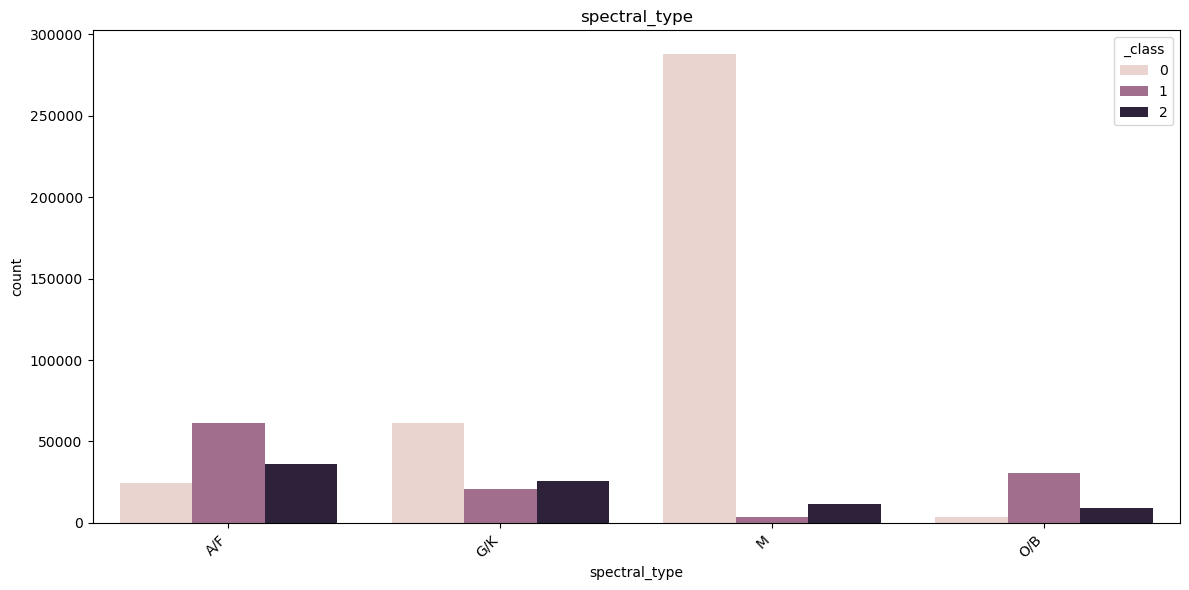

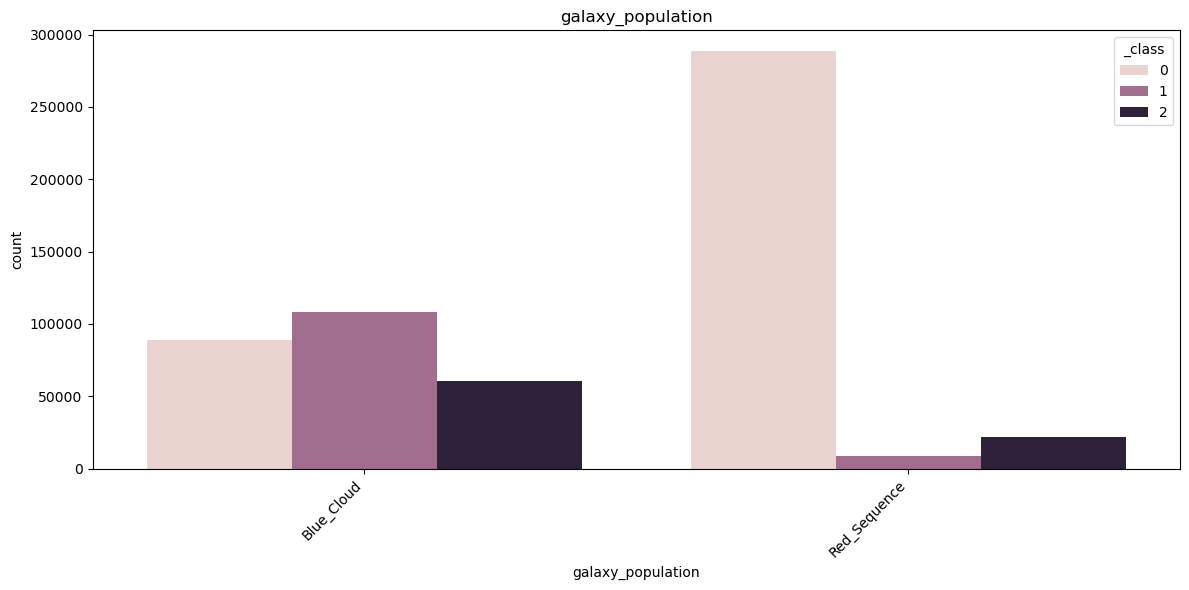

In [26]:
# Value counts for each categorical column, split by Churn
# churn_col = 'PitNextLap' if 'PitNextLap' in train_df.columns else 'pitnextlap'
churn_col = target
for f in df.select_dtypes(include=['object']).columns:
    if f == churn_col:
        continue
    plot_df = df.groupby([f, churn_col]).size().reset_index(name='count')
    sns.barplot(data=plot_df, x=f, y='count', hue=churn_col)
    plt.title(f)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Distributions (train vs test)

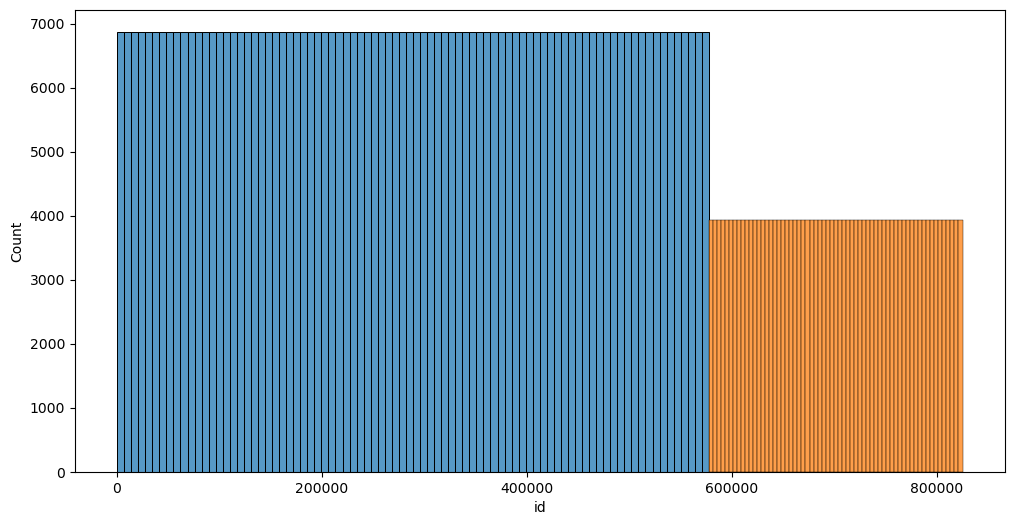

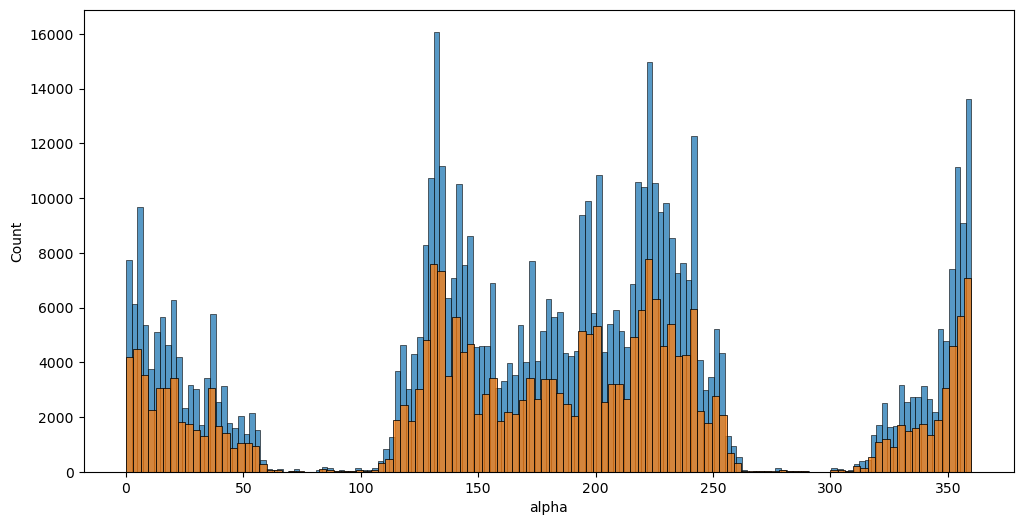

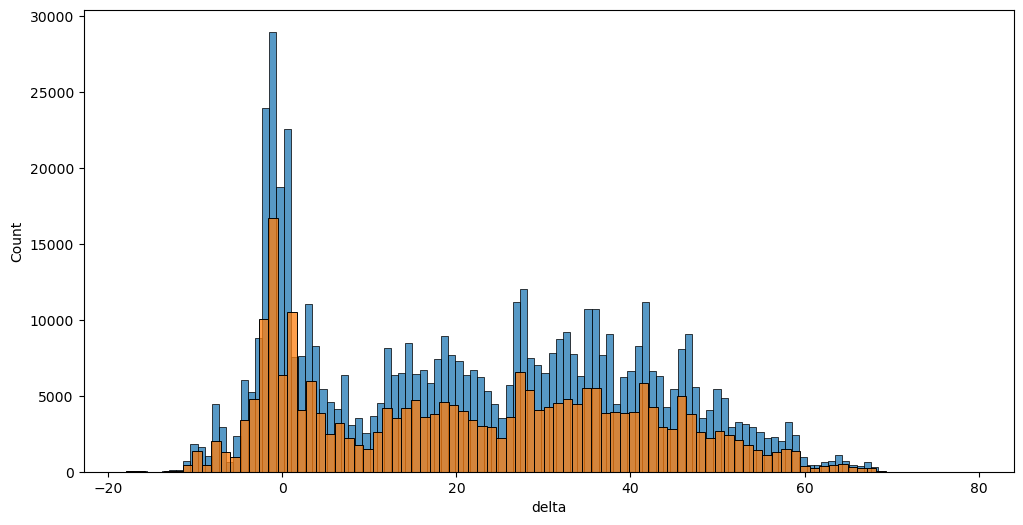

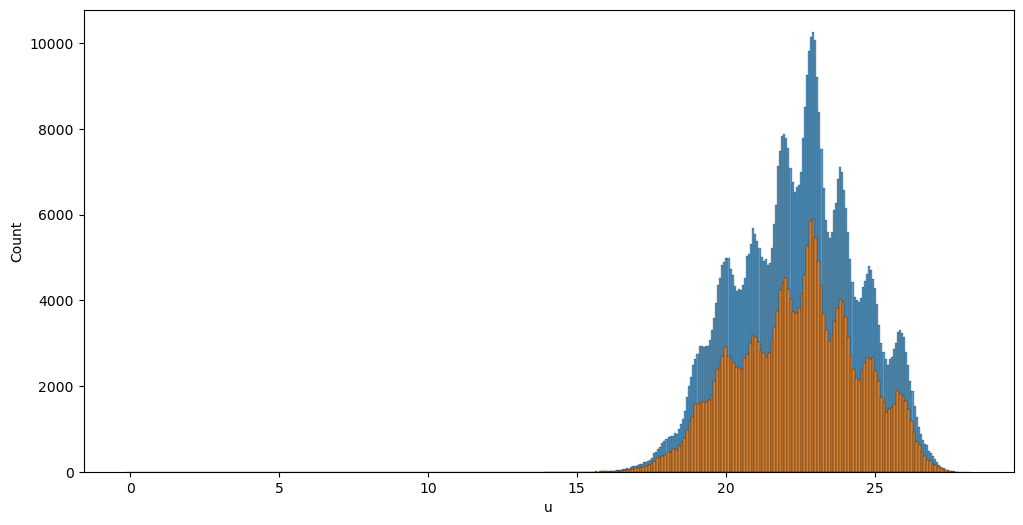

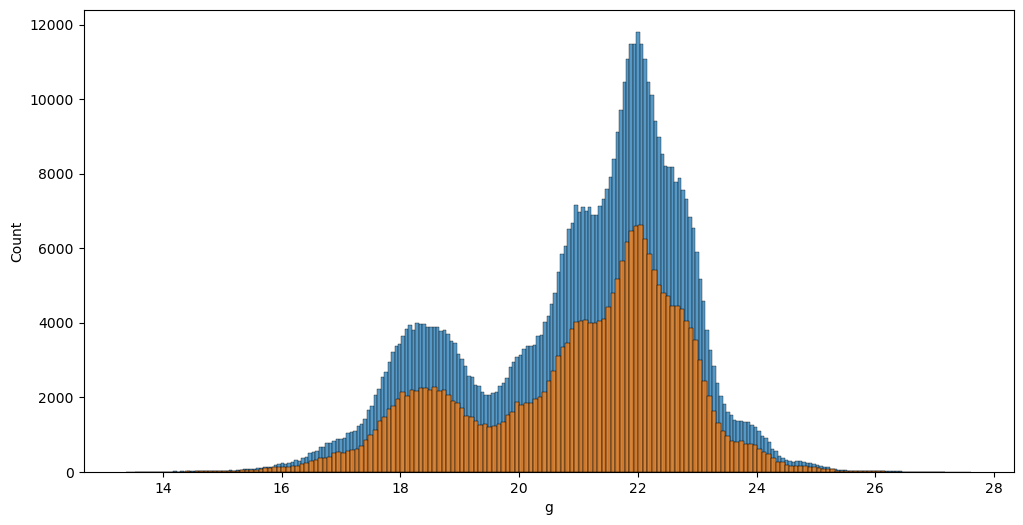

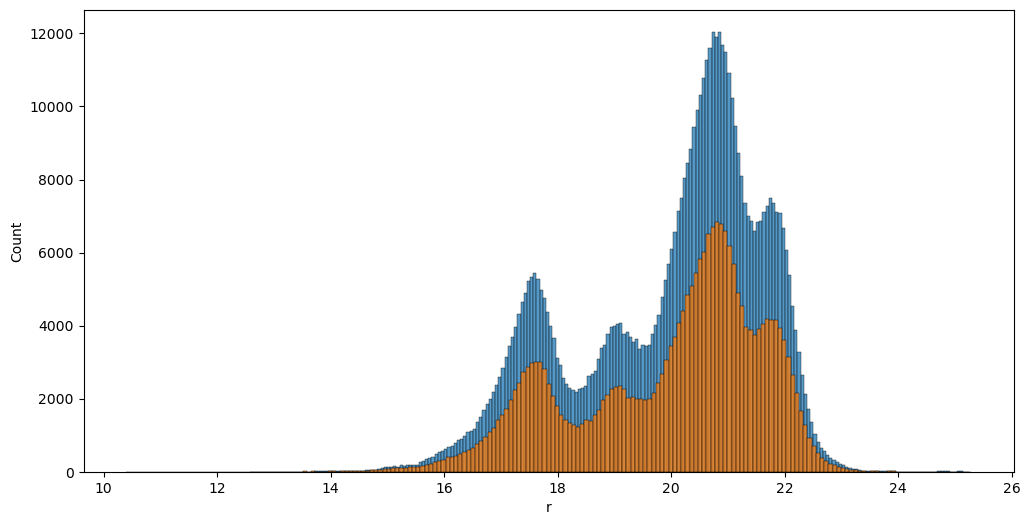

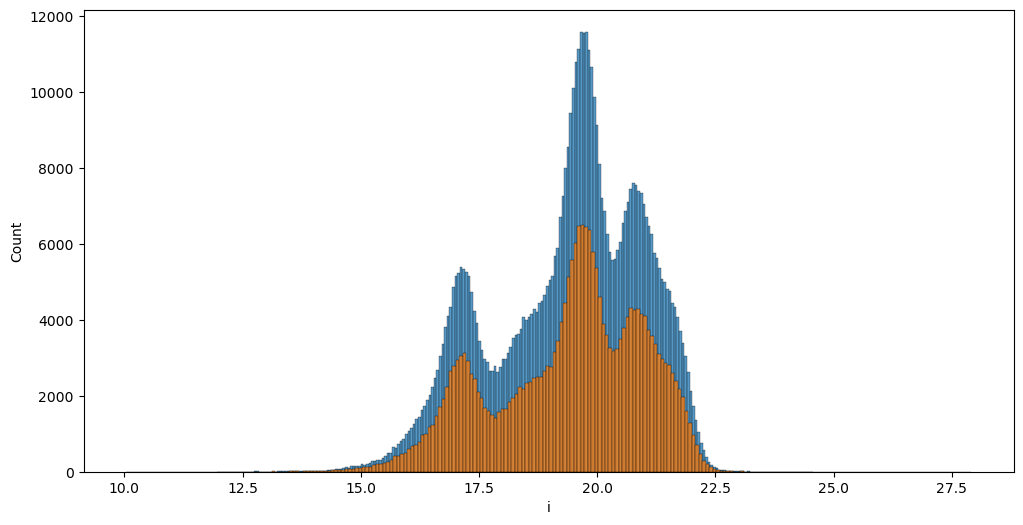

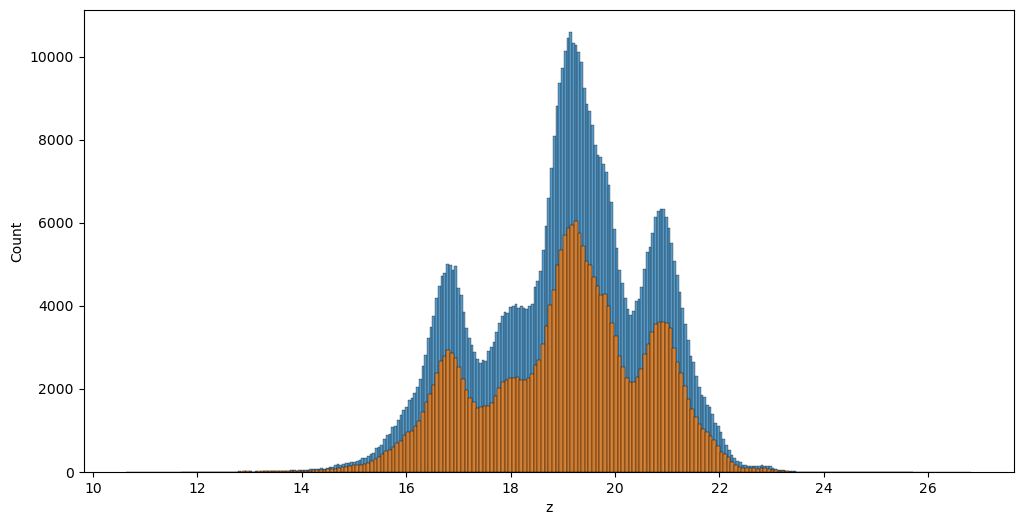

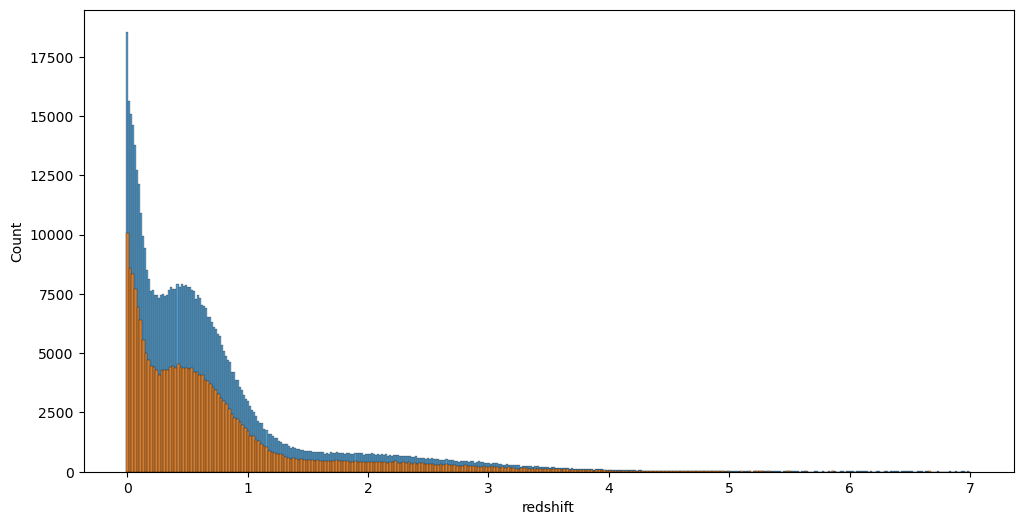

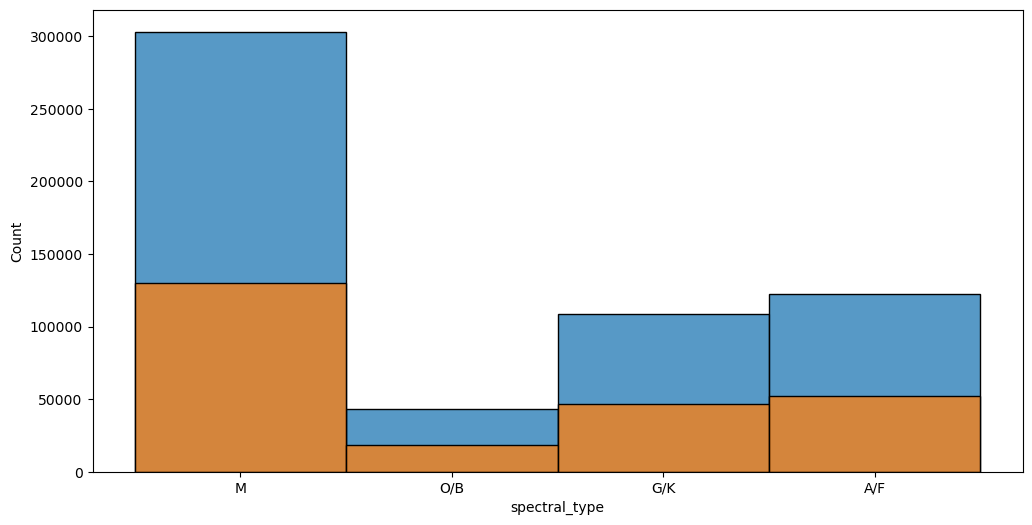

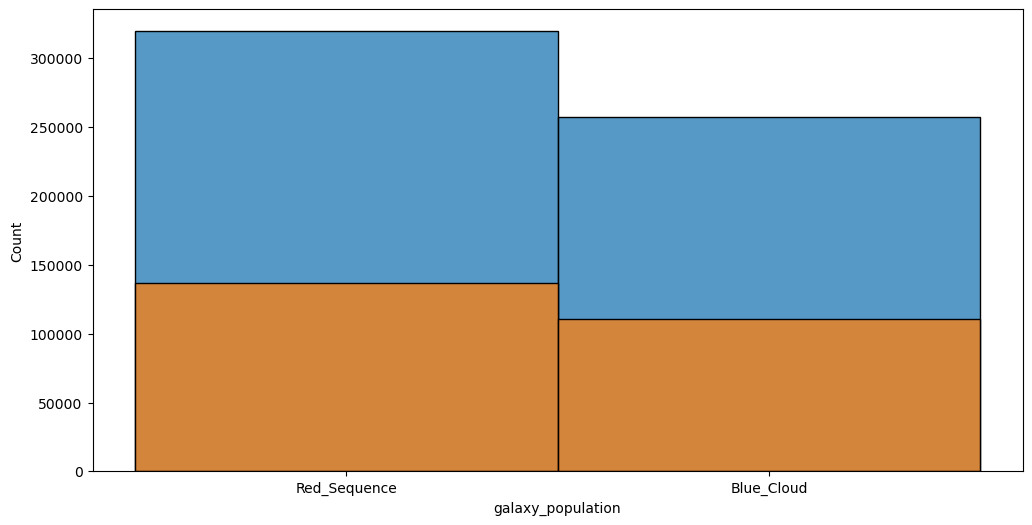

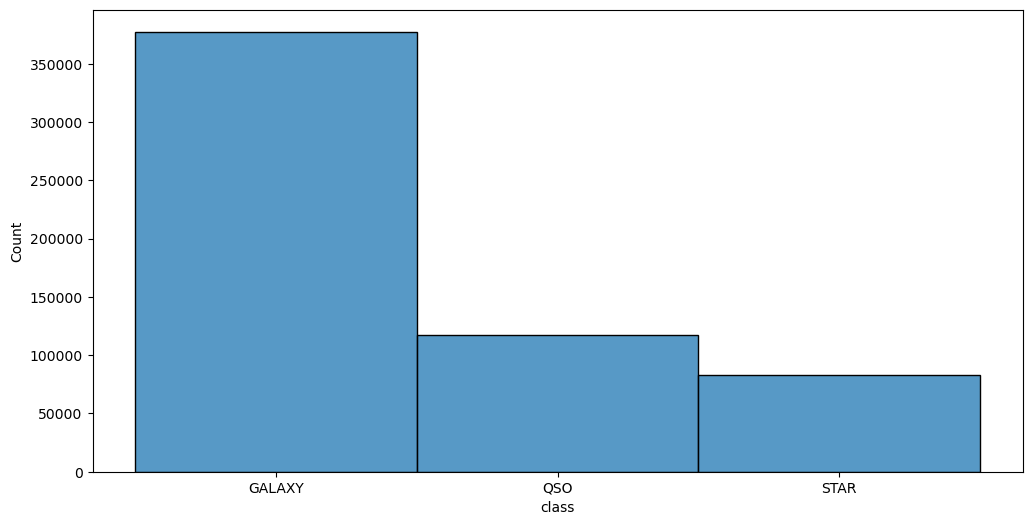

In [27]:
for col in train_df.columns:
    sns.histplot(train_df[col])
    if col in test_df.columns:
        sns.histplot(test_df[col])
    plt.show()

## Features

## Bar Charts

## Kmeans

## Scatter Plots

## Correlation Plots

In [28]:
df[target].value_counts()

_class
0    377480
1    117143
2     82724
Name: count, dtype: int64

In [29]:
df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,_class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0
...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,0
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,0
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,0
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,1


<Axes: >

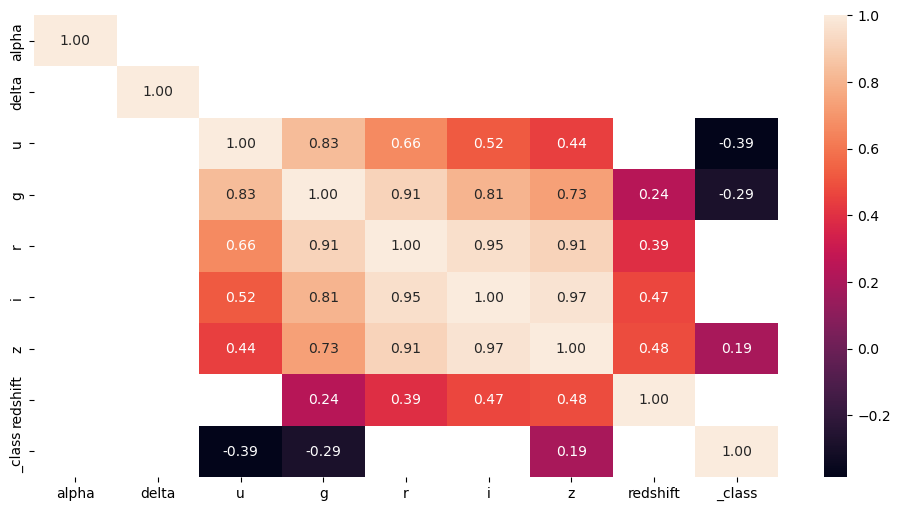

In [30]:
corr_matrix = df.corr(numeric_only=True)

mask = abs(corr_matrix) < 0.15

sns.heatmap(data=corr_matrix, mask=mask, fmt='.2f', annot=True)

<Axes: xlabel='_class'>

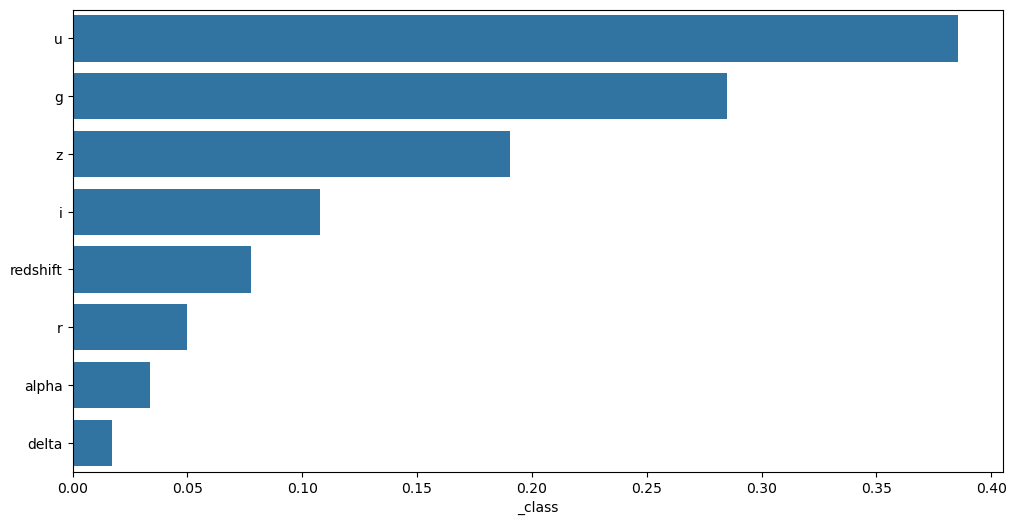

In [31]:
sns.barplot(corr_matrix[target].drop(target).abs().sort_values(ascending=False)[:15], orient='h')

In [32]:
corr_matrix[target].drop(target).abs().sort_values(ascending=False)[:15]

u           0.385667
g           0.285010
z           0.190467
i           0.107635
redshift    0.077758
r           0.049845
alpha       0.033585
delta       0.017359
Name: _class, dtype: float64

In [33]:
df.groupby(['compound'])['pitnextlap'].describe()

KeyError: 'compound'

In [ ]:
df['wet_race'] = df['compound'].map({'HARD': 0, 'MEDIUM': 0, 'SOFT': 0, 'INTERMEDIATE': 1, 'WET': 1}).value_counts()
df['dry_race'] = df['compound'].map({'HARD': 1, 'MEDIUM': 1, 'SOFT': 1, 'INTERMEDIATE': 0, 'WET': 0}).value_counts()

In [ ]:
df.groupby('race')['stint'].describe()

In [ ]:
df['race'].map(df.groupby('race')['stint'].median())

In [ ]:
aus_2022 = df.query("year == 2022").query("race == 'Austrian Grand Prix'").query("driver == 'BUT'").sort_values(by='lapnumber')

In [ ]:
aus_2022

In [ ]:
sns.lineplot(data=aus_2022, x='lapnumber', y='stint', hue='driver')

In [ ]:
aus_2022.query("driver == 'BUT'").groupby('lapnumber').size().value_counts()

In [ ]:
(df['stint'] == df['pitstop'] + 1).mean()

In [ ]:
orig_df

In [ ]:
orig_df.query("Year == 2022 and Race == 'Austrian Grand Prix' and Driver == 'HAM'").sort_values('LapNumber')[['Year', 'Race', 'Driver', 'LapNumber','Stint','PitStop','TyreLife']]  

In [ ]:
df['is_anon_driver'] = df['driver'].str.startswith('D')        
df.groupby('is_anon_driver').apply(lambda g: (g['stint'] == g['pitstop'] + 1).mean()) 

In [ ]:
df.groupby('pitstop')['pitnextlap'].mean()

In [ ]:
df.groupby('year')['pitnextlap'].mean()

In [ ]:
test_df['Year'].value_counts()

In [ ]:
orig_df.query("Year == 2023")['PitNextLap'].mean()

In [ ]:
train_df['Year'].value_counts(normalize=True), test_df['Year'].value_counts(normalize=True)

In [ ]:
test_df['Year'].value_counts(normalize=True)